In [1]:
import os
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse import hstack, kron, eye, csc_matrix, block_diag
import time
import quimb as qu
import quimb.tensor as qtn
from quimb.tensor.fitting import tensor_network_distance
from ncon import ncon
import torch
import warnings
import torch.optim as optim
from quimb.tensor import tensor_split
import cotengra as ctg
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau

fsize = 24
tsize = 24

tdir = 'in'
major = 7.5
minor = 4.5

style = 'default'

plt.style.use(style)
plt.rcParams['text.usetex'] = False
plt.rcParams['font.size'] = fsize
plt.rcParams['legend.fontsize'] = tsize
plt.rcParams['xtick.direction'] = tdir
plt.rcParams['ytick.direction'] = tdir
plt.rcParams['xtick.major.size'] = major
plt.rcParams['xtick.minor.size'] = minor
plt.rcParams['ytick.major.size'] = major
plt.rcParams['ytick.minor.size'] = minor
plt.rcParams["figure.figsize"] = (16,9)
plt.rcParams['axes.grid']=False
plt.rcParams['grid.alpha'] = 0.25
#mpl.rcParams.update({"axes.grid" : True, "grid.alpha": 0.25})
plt.rcParams['figure.dpi'] = 400
plt.rcParams['text.usetex'] = True


0.3859368121854837
[0.36012006 0.44503928 0.31890204 0.44379975 0.44670408 0.39880384
 0.4261207  0.25697167 0.41158639 0.2758453  0.37030673 0.38163455
 0.25461259 0.42445472 0.38107709 0.28243034 0.38064859 0.39786393
 0.42877179 0.40594042 0.31486604 0.18591419 0.41396662 0.45180496
 0.42288341 0.44385618 0.40611752 0.47937622 0.389098   0.45170349
 0.39728084 0.29009639 0.42114435 0.41626686 0.37486185 0.38782573
 0.43379232 0.39423316 0.25023176 0.45645209 0.43088371 0.45860968
 0.41090756 0.37791024 0.42526864 0.38479954 0.42276624 0.46329735
 0.25603439 0.46009515 0.46500883 0.32740204 0.40827958 0.40156079
 0.15258384 0.43602323 0.37131681 0.36409754 0.41175756 0.33592498
 0.4290207  0.43433558 0.39478339 0.43936597 0.36040617 0.36790674
 0.24658278 0.41719525 0.41487313 0.48420849 0.36656171 0.33083214
 0.29650389 0.43075855 0.40376547 0.44374932 0.43505604 0.40231692
 0.3068781  0.44646306 0.46928718 0.31940228 0.3456493  0.40894037
 0.40256844 0.22876235 0.34733617 0.3772873

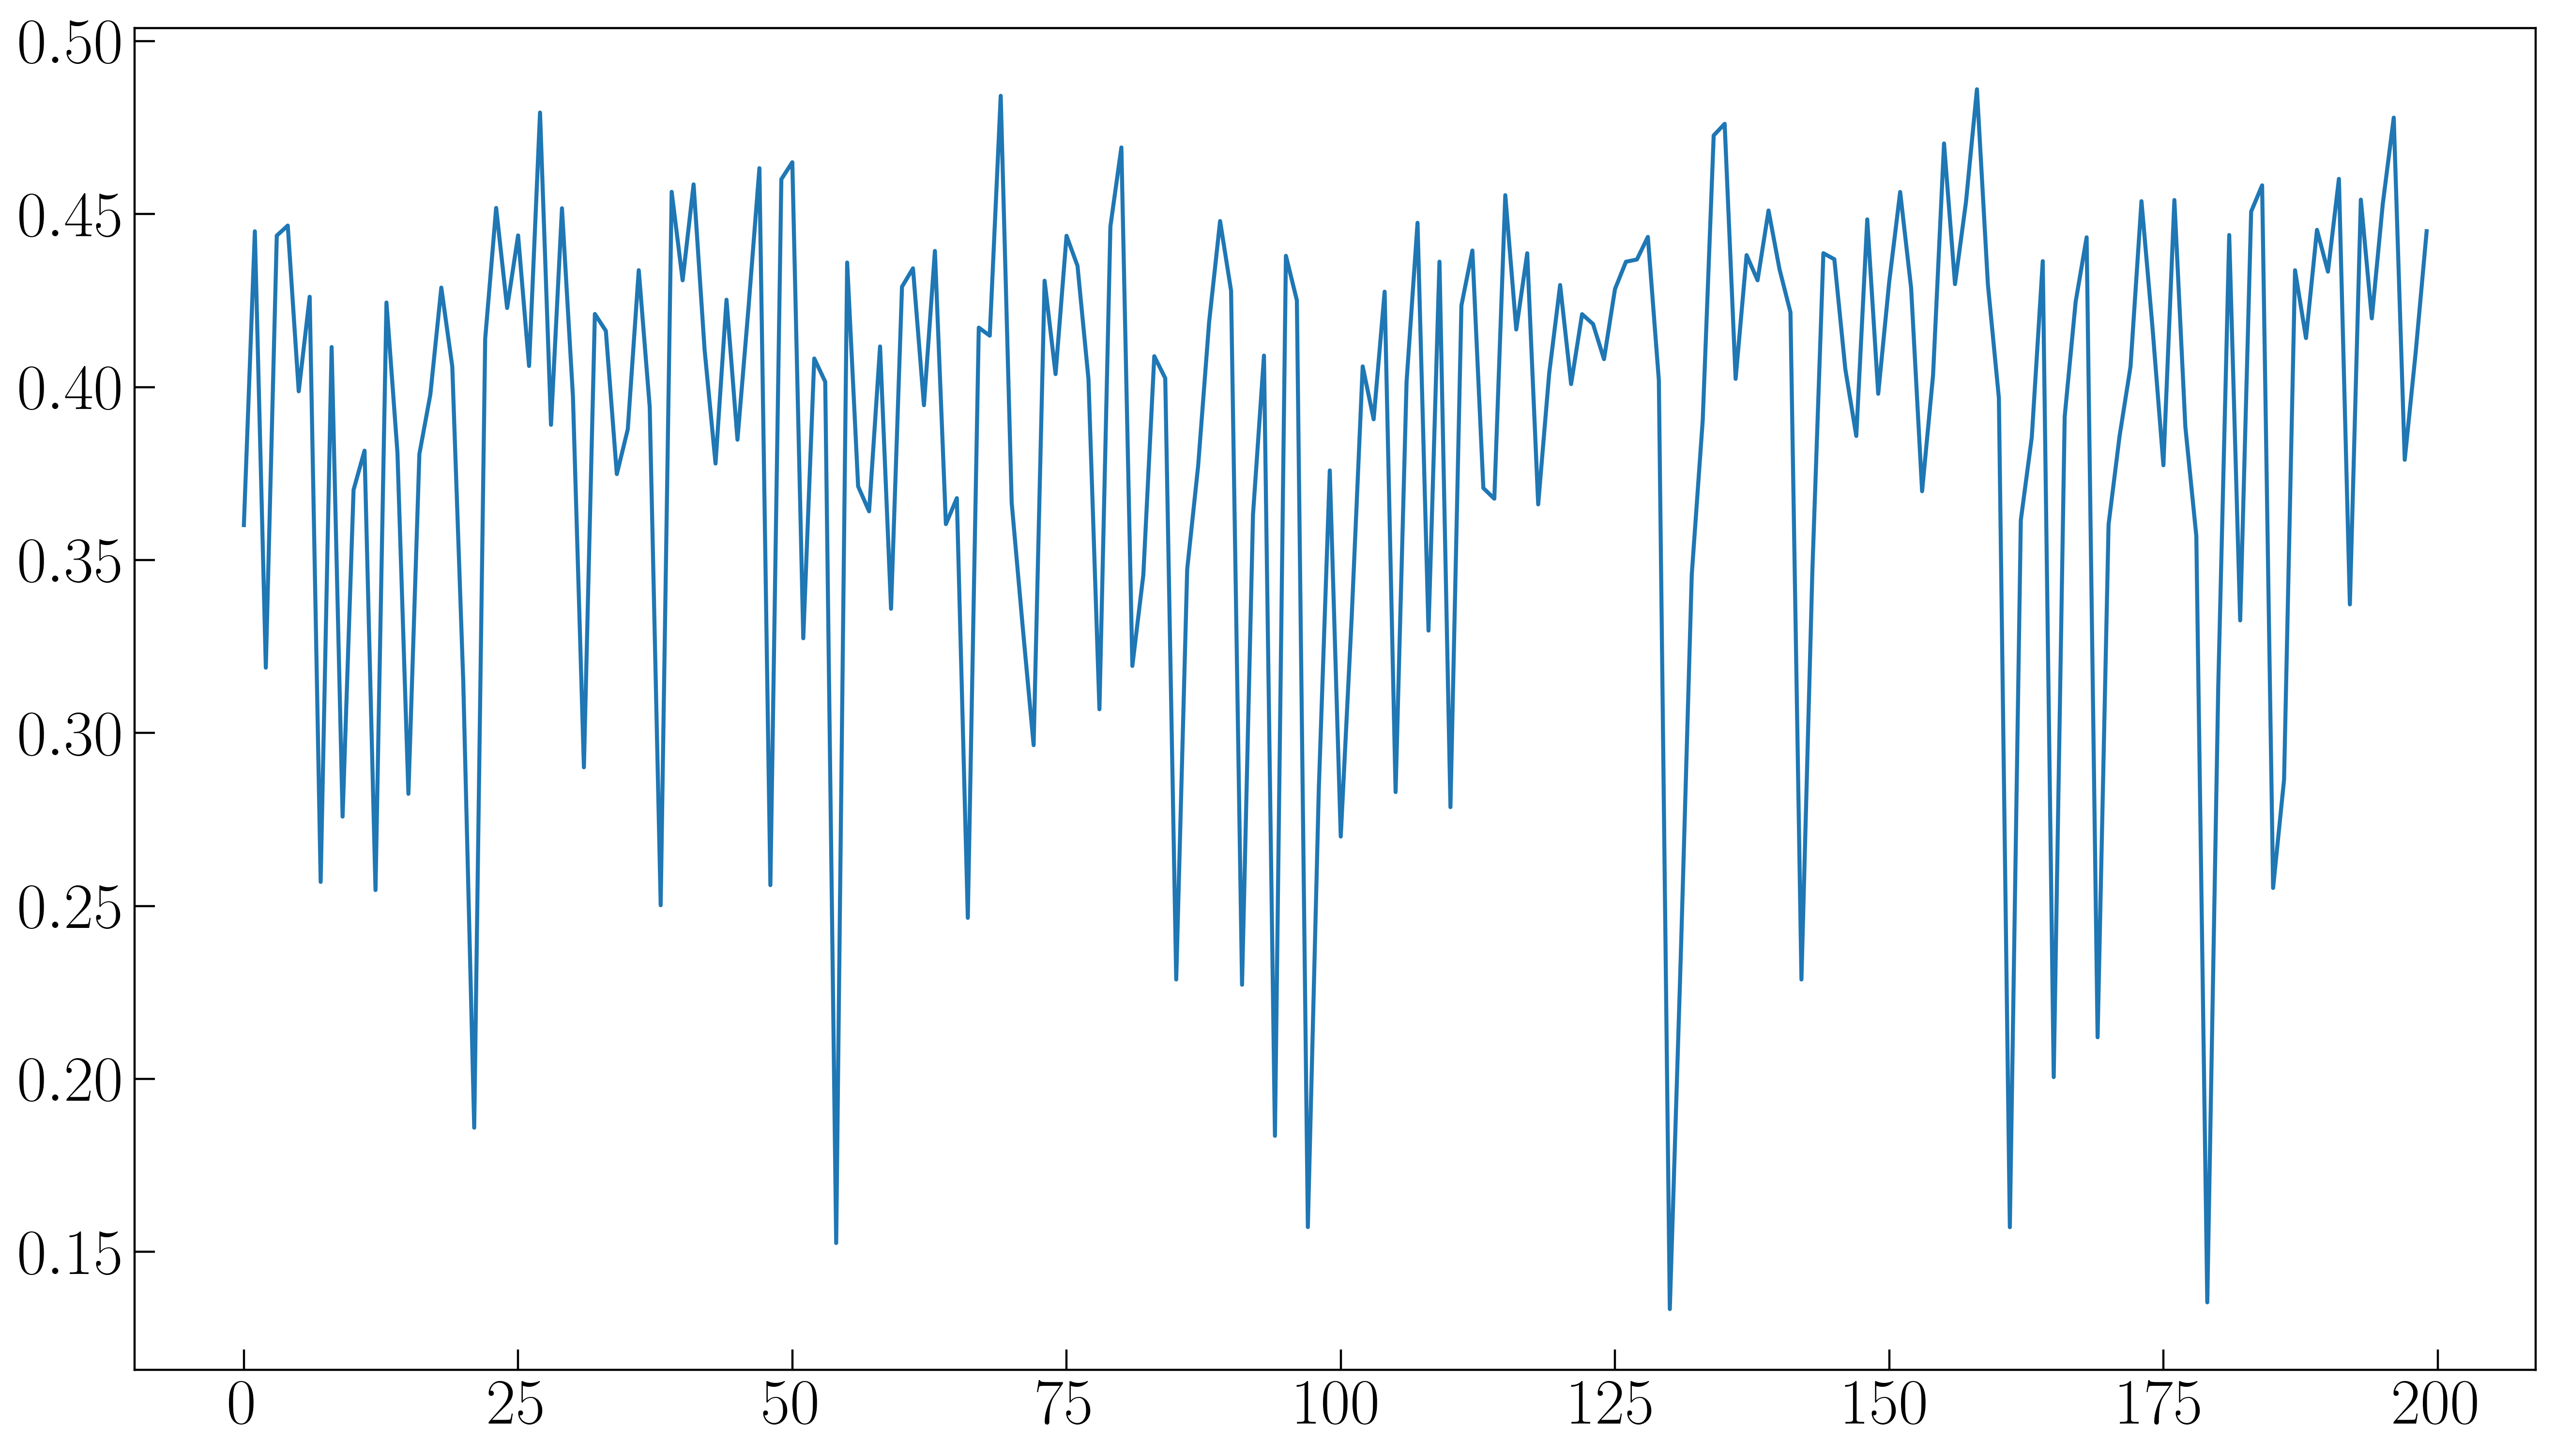

In [6]:
training_loss = np.load("TDME_N10_T3_Modeltolearnlayer3_time0.6_gamma000_learning_loss.npy")
testing_loss = np.load("TDME_N10_T3_Modeltolearnlayer3_time0.6_gamma000_testing_loss.npy")
testing_loss_list = np.load("TDME_N10_T3_Modeltolearnlayer3_time0.6_gamma000_testing_loss_list.npy")
print(testing_loss)
print(testing_loss_list)
plt.plot(testing_loss_list)